# Plant Health Detection Project
## 1. Import

In [3]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
import numpy as np
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models

In [34]:
AUTOTUNE = tf.data.AUTOTUNE

In [ ]:
train_dir = 'train'
valid_dir = 'valid'

## Loading Traning Set

In [ ]:
training_set = tf.keras.utils.image_dataset_from_directory(
    'train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=16,          # Set to 16 to accommodate EfficientNet constraints
    image_size=(128, 128),
    shuffle=True,
    interpolation="bilinear"
)

Found 70295 files belonging to 38 classes.


## Loading Validation Set

In [ ]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=16,
    image_size=(128, 128),
    shuffle=True,
    interpolation="bilinear"
)

Found 17572 files belonging to 38 classes.


### Data Augmentation

In [38]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.08),  # Corresponds to roughly 30 degrees max
    tf.keras.layers.RandomTranslation(height_factor=0.2, width_factor=0.2),
    tf.keras.layers.RandomBrightness(factor=0.3) # Ranges variation roughly [0.7, 1.3]
])

In [39]:
training_set = training_set.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
training_set = training_set.prefetch(buffer_size=AUTOTUNE)

# Validation doesn't need augmentation, just cache and prefetch
validation_set = validation_set.cache().prefetch(buffer_size=AUTOTUNE)

# Phase 3: Building ML Model 
# Building ML Model using EfficientNetB0 Model

In [40]:
base_model = EfficientNetB0(
    input_shape=(128, 128, 3),
    include_top=False,
    weights='imagenet'
)

In [ ]:
# 1. Unfreeze the base model weights for fine-tuning
base_model.trainable = True

# 2. Define the model architecture 
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(38, activation='softmax')
])

# 3. Compile model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## Set up Callbacks

In [ ]:
# Training Callbacks configuration
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath='plant_health_model_best.h5',
        save_best_only=True,
        monitor='val_accuracy'
    )
]

## Start Training

In [43]:
history = model.fit(
    training_set,
    validation_data=validation_set,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.6893 - loss: 1.1518

4394/4394 ━━━━━━━━━━━━━━━━━━━━ 466s 90ms/step - accuracy: 0.8494 - loss: 0.5274 - val_accuracy: 0.9688 - val_loss: 0.0994
Epoch 2/10
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.9503 - loss: 0.1517

4394/4394 ━━━━━━━━━━━━━━━━━━━━ 395s 90ms/step - accuracy: 0.9573 - loss: 0.1323 - val_accuracy: 0.9845 - val_loss: 0.0446
Epoch 3/10
4393/4394 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.9686 - loss: 0.0995

4394/4394 ━━━━━━━━━━━━━━━━━━━━ 376s 86ms/step - accuracy: 0.9716 - loss: 0.0896 - val_accuracy: 0.9895 - val_loss: 0.0310
Epoch 4/10
4393/4394 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.9770 - loss: 0.0726

4394/4394 ━━━━━━━━━━━━━━━━━━━━ 377s 86ms/step - accuracy: 0.9781 - loss: 0.0693 - val_accuracy: 0.9912 - val_loss: 0.0256
Epoch 5/10
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.9811 - loss: 0.0565

4394/4394 ━━━━━━━━━━━━━━━━━━━━ 373s 85ms/step - accuracy: 0.9817 - loss: 0.0553 - val_accuracy: 0.9915 - val_loss: 0.0271
Epoch 6/10
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 385s 88ms/step - accuracy: 0.9838 - loss: 0.0487 - val_accuracy: 0.9904 - val_loss: 0.0334
Epoch 7/10
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.9858 - loss: 0.0441

4394/4394 ━━━━━━━━━━━━━━━━━━━━ 370s 84ms/step - accuracy: 0.9859 - loss: 0.0435 - val_accuracy: 0.9940 - val_loss: 0.0191
Epoch 8/10
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 372s 85ms/step - accuracy: 0.9871 - loss: 0.0390 - val_accuracy: 0.9905 - val_loss: 0.0272
Epoch 9/10
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 377s 86ms/step - accuracy: 0.9886 - loss: 0.0360 - val_accuracy: 0.9937 - val_loss: 0.0225
Epoch 10/10
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.9883 - loss: 0.0361

4394/4394 ━━━━━━━━━━━━━━━━━━━━ 386s 88ms/step - accuracy: 0.9887 - loss: 0.0349 - val_accuracy: 0.9964 - val_loss: 0.0137


# Phase 4: Model Evaluation
## Accuracy Visualization

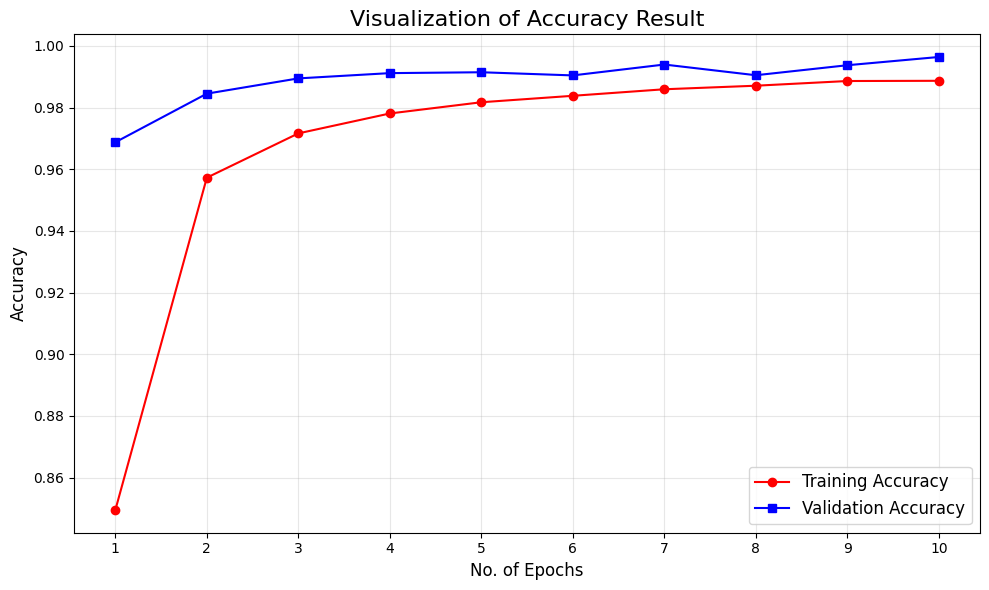

In [44]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], color='red', label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], color='blue', label='Validation Accuracy', marker='s')

# Fixed tick-shifting setup
epochs = range(len(history.history['accuracy']))
epoch_labels = range(1, len(history.history['accuracy']) + 1)
plt.xticks(ticks=epochs, labels=epoch_labels)

plt.title('Visualization of Accuracy Result', fontsize=16)
plt.xlabel('No. of Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right', fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [45]:
print("Generating evaluation metrics on validation set...")

# 1. Extract true labels efficiently from the validation generator
y_true_list = []
for _, labels in validation_set:
    y_true_list.extend(np.argmax(labels.numpy(), axis=1))
y_true = np.array(y_true_list)

# 2. Extract raw probability distributions in one fast, optimized batch step
y_pred_probs = model.predict(validation_set, verbose=1)

# 3. Convert probabilities to hard class indices
y_pred = np.argmax(y_pred_probs, axis=1)

print(f"Extraction complete. Target shape: {y_true.shape}, Prediction shape: {y_pred.shape}")

Generating evaluation metrics on validation set...
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 30s 18ms/step
Extraction complete. Target shape: (17572,), Prediction shape: (17572,)


In [46]:
# Check for class_names globally; recover directly from validation pipeline if missing
if 'class_names' not in locals() and 'class_names' not in globals():
    try:
        class_names = validation_set.class_names
        print("Successfully recovered class names from validation set.")
    except AttributeError:
        class_names = [f"Class {i}" for i in range(38)]
        print("Validation set attribute missing. Generated numeric placeholder classes (0-37).")
else:
    print("Using existing class_names variable found in notebook memory.")

Using existing class_names variable found in notebook memory.


## Confusion Matrix

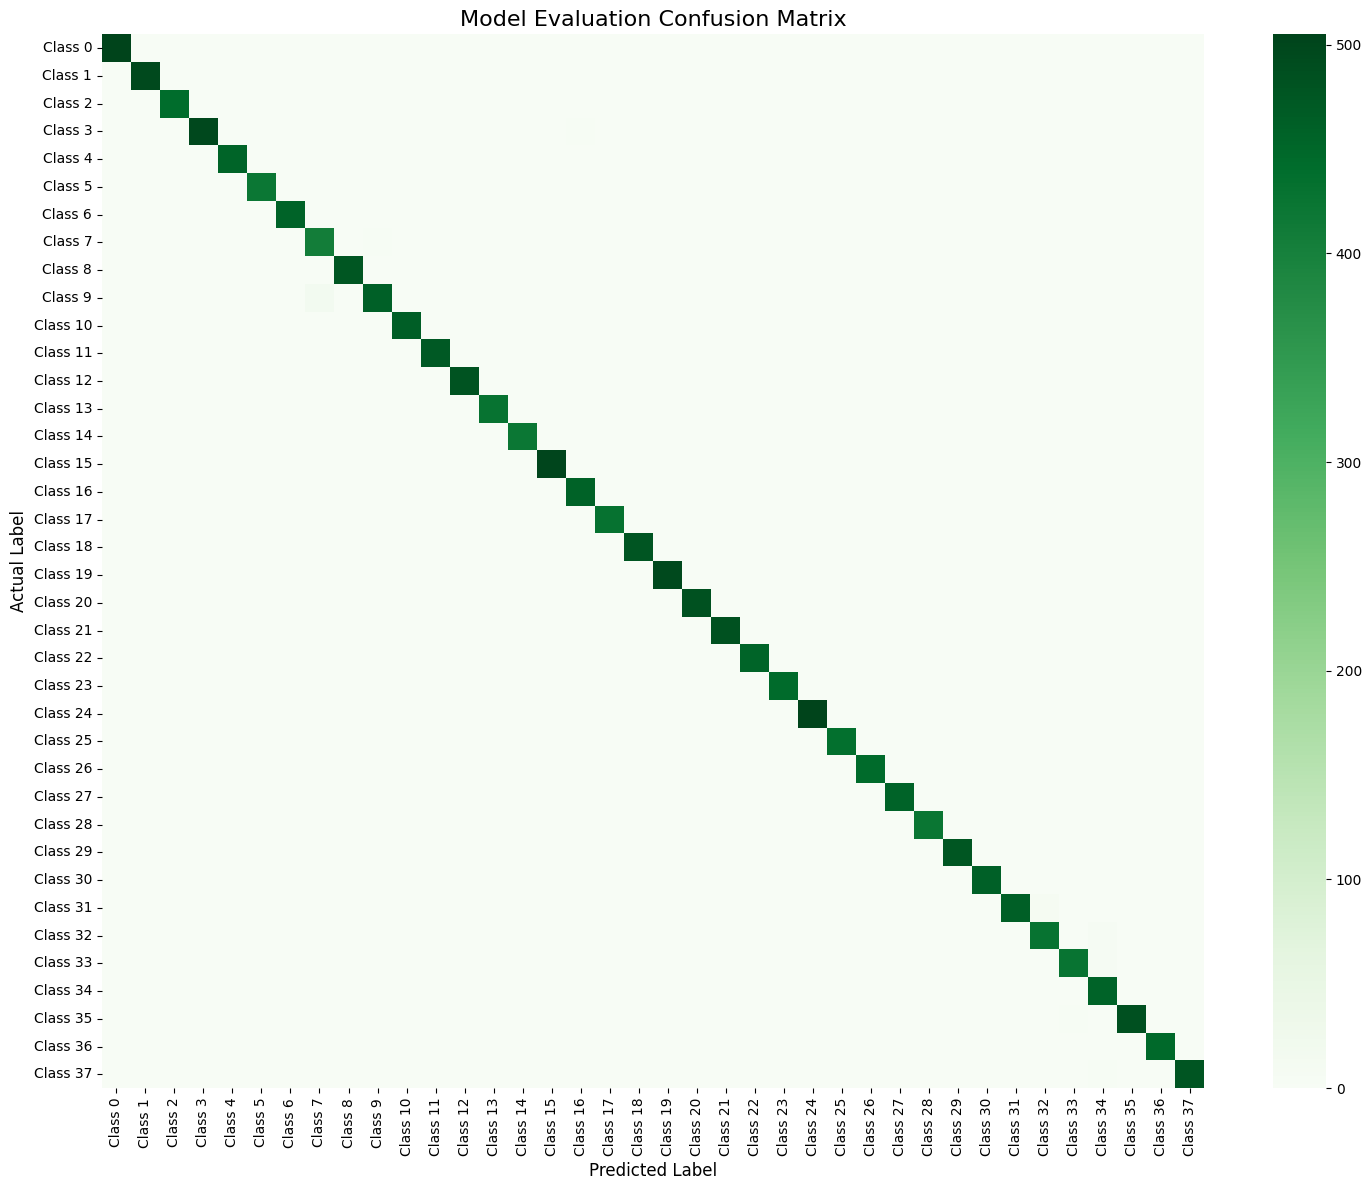

In [47]:
# Compute matrix
cm = confusion_matrix(y_true, y_pred)

# Build Heatmap
plt.figure(figsize=(15, 12))
sns.heatmap(cm, annot=False, cmap='Greens', xticklabels=class_names, yticklabels=class_names)
plt.title("Model Evaluation Confusion Matrix", fontsize=16)
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

## ROC Curve

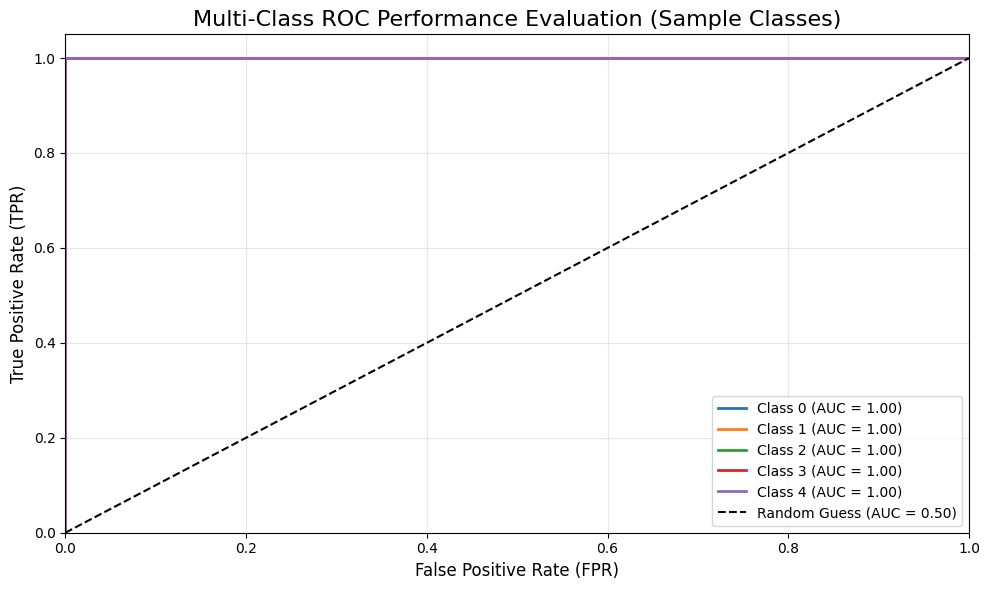

In [48]:
# Binarize labels for multi-class ROC calculation
y_true_bin = label_binarize(y_true, classes=list(range(38)))

fpr = dict()
tpr = dict()
roc_auc = dict()

# Compute ROC curve and AUC area for every individual class
for i in range(38):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plotting a subset snippet (e.g., first 5 classes) to keep the graph readable
plt.figure(figsize=(10, 6))
for i in range(5):
    plt.plot(fpr[i], tpr[i], label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})', linewidth=2)

# Plot baseline random-guess diagonal line
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('Multi-Class ROC Performance Evaluation (Sample Classes)', fontsize=16)
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
y_true_list = []
y_pred_probs_list = []

# Loop through the dataset once to collect BOTH true labels and predictions together
for images, labels in validation_set:
    # 1. Grab true classes for this batch
    y_true_list.extend(np.argmax(labels.numpy(), axis=1))

    # 2. Grab raw predictions for this batch
    preds = model.predict(images, verbose=0)
    y_pred_probs_list.extend(preds)

# Convert both arrays at the exact same time
y_true = np.array(y_true_list)
y_pred_probs = np.array(y_pred_probs_list)
y_pred = np.argmax(y_pred_probs, axis=1)

print(f"Success! y_true size: {len(y_true)} | y_pred size: {len(y_pred)}")

Synchronizing true labels and predictions...
Success! y_true size: 17572 | y_pred size: 17572


## Classification Report

In [54]:
from sklearn.metrics import classification_report

# Print the text-based classification report
# 'digits=2' ensures your scores show up as 0.98, 0.95, etc.
print(classification_report(y_true, y_pred, target_names=class_names, digits=2))

              precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00       504
     Class 1       1.00      1.00      1.00       497
     Class 2       1.00      1.00      1.00       440
     Class 3       1.00      0.99      1.00       502
     Class 4       1.00      1.00      1.00       454
     Class 5       1.00      1.00      1.00       421
     Class 6       1.00      1.00      1.00       456
     Class 7       0.96      0.99      0.98       410
     Class 8       1.00      1.00      1.00       477
     Class 9       0.99      0.97      0.98       477
    Class 10       1.00      1.00      1.00       465
    Class 11       1.00      1.00      1.00       472
    Class 12       1.00      1.00      1.00       480
    Class 13       1.00      1.00      1.00       430
    Class 14       1.00      1.00      1.00       423
    Class 15       1.00      1.00      1.00       503
    Class 16       1.00      1.00      1.00       459
    Class 17       1.00    